In [35]:
!pip install networkx numpy matplotlib scipy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import time
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [37]:
def translate_in_list(G, n_left, n_right):
    g = [[] for _ in range(n_left)]
    for v in range(n_left):
        for u in G.neighbors(v):
            if u >= n_left:
                g[v].append(u - n_left)
    return g

In [38]:
def kuhn_matching(g, left_v, right_v):
    match = [-1] * right_v
    used = [0] * left_v

    def obhod_v_glubinu(v):
        if used[v] == 1:
            return False
        used[v] = 1

        for kuda_idem in g[v]:
            if match[kuda_idem] == -1 or obhod_v_glubinu(match[kuda_idem]):
                match[kuda_idem] = v
                return True

        return False

    for v in range(left_v):
        used = [0] * left_v
        obhod_v_glubinu(v)

    pairs = []
    for y in range(right_v):
        if match[y] != -1:
            pairs.append((match[y], y))

    return pairs

In [39]:
times = []
G = nx.bipartite.random_graph(35000, 35000, 0.00001)
g = translate_in_list(G, 35000, 35000)
for i in range(100):
    start = time.perf_counter()
    pairs = kuhn_matching(g, 35000, 35000)
    end = time.perf_counter()
    times.append(end-start)
print(times)

[2.4139234999893233, 2.418432000093162, 2.3950713999802247, 2.4206153999548405, 2.442566900048405, 2.4620849000057206, 2.4110616999678314, 2.4373690000502393, 2.3996633000206202, 2.430990800028667, 2.422809900017455, 2.3930850999895483, 2.4329255999764428, 2.436350099975243, 2.418110299971886, 2.4395413999445736, 2.4318258999846876, 2.4443404999328777, 2.450588700012304, 2.420780299929902, 2.4405857999809086, 2.44613129994832, 2.442534900037572, 2.4403082999633625, 2.4437961999792606, 2.457674100063741, 2.4356049000052735, 2.4429538000840694, 2.4462327000219375, 2.4667095000622794, 2.4424331000773236, 2.448580500087701, 2.455317300045863, 2.4659915999509394, 2.461547699989751, 2.438004900002852, 2.473874800023623, 2.4286785000003874, 2.458103199955076, 2.421731899958104, 2.4673970999429002, 2.499102000030689, 2.474531199899502, 2.4550387000199407, 2.4270788999274373, 2.4583787999581546, 2.403052099980414, 2.4563147999579087, 2.4491452999645844, 2.4590649000601843, 2.4436568000819534, 2

In [40]:
times = np.array(times)
times.mean(), times.std()

(np.float64(2.43496837199782), np.float64(0.14150530931530106))

In [56]:
ns = list(range(2500, 35000, 2500))
means = []
stds = []
for n in ns:
    times = []
    G = nx.bipartite.random_graph(n, n, 0.00001)
    g = translate_in_list(G, n, n)
    for _ in range(50):
        start = time.perf_counter()
        kuhn_matching(g, n, n)
        end = time.perf_counter()
        times.append(end - start)
    times = np.array(times)
    means.append(times.mean())
    stds.append(times.std())

means = np.array(means)
stds = np.array(stds)

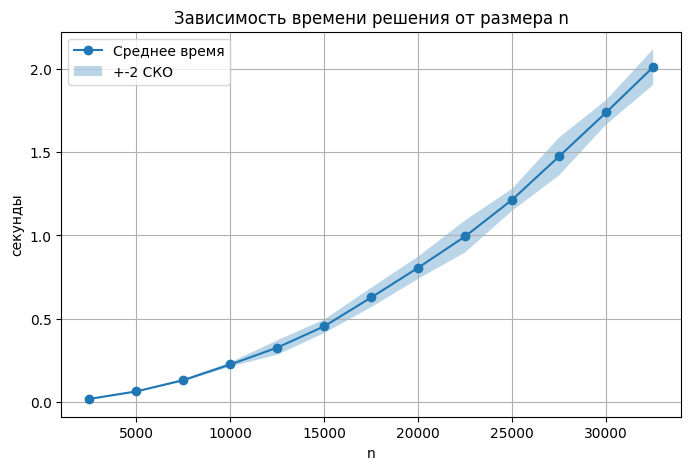

In [68]:
plt.figure(figsize=(8, 5))
plt.plot(ns, means, marker='o', label='Среднее время')
plt.fill_between(ns, means - 2 * stds, means + 2 * stds, alpha=0.3, label='+-2 СКО')
plt.xlabel('n')
plt.ylabel('секунды')
plt.title('Зависимость времени решения от размера n')
plt.grid(True)
plt.legend()
plt.show()

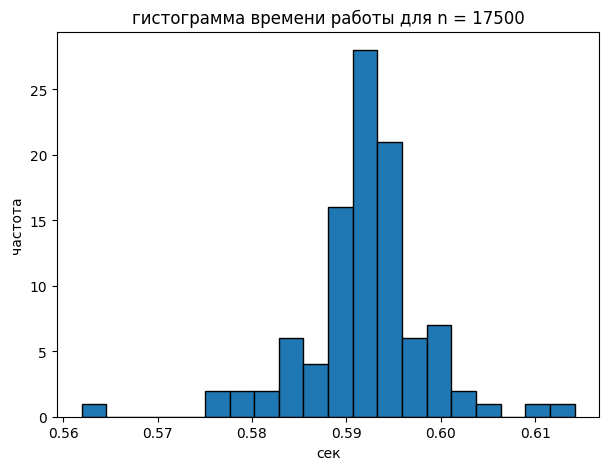

In [62]:
n = 17500
times = []
G = nx.bipartite.random_graph(n, n, 0.00001)
g = translate_in_list(G, n, n)
for _ in range(100):
    G = nx.bipartite.random_graph(n, n, 0.00001)
    g = translate_in_list(G, n, n)
    start = time.perf_counter()
    kuhn_matching(g, n, n)
    end = time.perf_counter()
    times.append(end - start)

plt.figure(figsize=(7,5))
plt.hist(times, bins=20, edgecolor='black')
plt.xlabel("сек")
plt.ylabel("частота")
plt.title(f"гистограмма времени работы для n = 17500")
plt.show()

In [64]:
times = np.array(times)
mu = times.mean()
sigma = times.std(ddof=1)
k = int(np.sqrt(len(times))) 
observed, bin_edges = np.histogram(times, bins=k)
expected = []
n_obs = len(times)

for i in range(len(bin_edges) - 1):
    left = bin_edges[i]
    right = bin_edges[i + 1]
    p = stats.norm.cdf(right, loc=mu, scale=sigma) - stats.norm.cdf(left, loc=mu, scale=sigma)
    expected.append(n_obs * p)
expected = np.array(expected)
expected = expected * observed.sum() / expected.sum()
chi2_stat, p_value = stats.chisquare(observed, expected)

print(f'mu = {mu}')
print(f'sigma = {sigma}')
print(f'chi2 = {chi2_stat}')
print(f'p-value = {p_value}')
print('гипотеза не отвергается' if p_value > 0.05 else 'гипотеза отвергается')

mu = 0.5920705060090404
sigma = 0.006586481737035306
chi2 = 148.7812528339046
p-value = 1.5771265714520269e-27
гипотеза отвергается


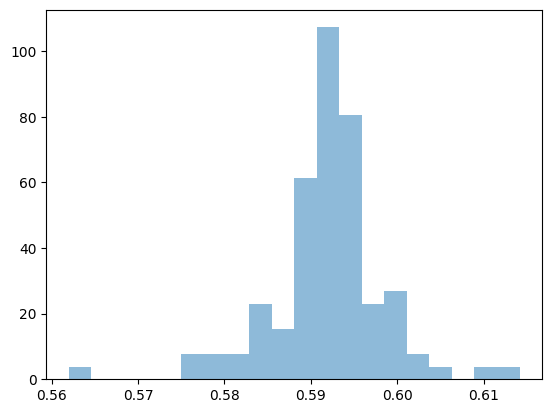

In [67]:
df1 = times.mean() #через метод моментов
df2 = times.var() / 2
df = int((df1 + df2) / 2)
x = np.linspace(min(times), max(times), 500)
plt.hist(times, bins=20, density=True, alpha=0.5)
plt.plot(x, stats.chi2.pdf(x, df=df))
plt.show()